# Identifiability evaluation report

Trustworthy evaluation of the multi-view content/style model, organised by how
well each metric matches what the model actually **claims** (Yao 2024 *block*
identifiability of content) and how robust it is to the synthetic factor
structure (a **causal SCM** — content factors are dependent).

**Two governing principles**

1. The theory guarantees the content *subspace* up to an invertible transform —
   **not** one-channel-one-factor. So axis-alignment metrics (DCI-D, per-channel
   MCC) test a claim the model does not make.
2. The content factors come from a causal SCM, so they are **correlated**. DCI's
   disentanglement/completeness assume *independent* factors, so D/C are bounded
   below 1 regardless of the model.

**Tiers** (this notebook)

* **Tier 1 (trust):** content informativeness (per factor, k-fold CV, multi-seed,
  patch-pooled) + partial-R² vs SCM parents; content/style separation; block-MCC.
* **Tier 2 (useful):** DCI *informativeness* only; probe-free cross-view
  consistency; causal partial-R².
* **Tier 3 (diagnostic, NOT claimed):** DCI D/C, per-channel MCC, kept because you
  want to track component-wise identifiability even though it isn't the target.

All metrics live in `eval/identifiability_metrics.py` (unit-testable); the cells
below just feed it the encoded features. Run the setup section first (it needs
your checkpoint).

## 0. Setup — load model, build dataset, encode, split (needs your checkpoint)

In [1]:
import os, sys, json

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# ---- USER CONFIG ---------------------------------------------------------
CHECKPOINT_PATH = "/home/ng24/projects/multiview-crl/results/synthetic/synthetic-causal-random-adv-loss-48-scale-4/vqvae_best.pt"  # <-- edit
NUM_SAMPLES = 500  # samples to encode for probing
PROBE_TYPES = ("linear", "mlp")  # set to ("linear",) to skip MLP
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SYNTHETIC_NORMALIZE = None  # None = read from settings.json; "per_sample" or "shared" to override
# --------------------------------------------------------------------------

settings_path = os.path.join(os.path.dirname(CHECKPOINT_PATH), "settings.json")
with open(settings_path) as f:
    settings = json.load(f)

# Resolve normalization: explicit override > settings.json > "per_sample" (legacy default)
if SYNTHETIC_NORMALIZE is not None:
    synthetic_normalize = SYNTHETIC_NORMALIZE
else:
    synthetic_normalize = settings.get("synthetic_normalize", "per_sample")

print(f"Loaded settings from {settings_path}")
print(f"  dataset_name      : {settings.get('dataset_name')}")
print(f"  synthetic_mode    : {settings.get('synthetic_mode')}")
print(f"  vqvae_nb_levels   : {settings.get('vqvae_nb_levels')}")
print(f"  content_style_lvls: {settings.get('content_style_levels')}")
print(f"  synthetic_normalize: {synthetic_normalize}")

Loaded settings from /home/ng24/projects/multiview-crl/results/synthetic/synthetic-causal-random-adv-loss-48-scale-4/settings.json
  dataset_name      : synthetic
  synthetic_mode    : pseudo_mri
  vqvae_nb_levels   : 1
  content_style_lvls: [0]
  synthetic_normalize: per_sample


## 1. Build & load the VQ-VAE


In [2]:
import models.vqvae as vqvae

# Match the construction used in main_multimodal.py for VQ-VAE.
# Pull the per-level content_channels from the checkpoint when possible
# (so we don't need to recompute them from ratios).
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint["encoders"]
prefix = "online." if any(k.startswith("online.") for k in state_dict) else ""

hidden_channels = settings["vqvae_hidden_channels"]
nb_levels = settings["vqvae_nb_levels"]
embed_dim = settings["vqvae_embed_dim"]
content_style_levels = settings.get("content_style_levels", [0])

# Per-level content_channels detection from codebook conv_in widths.
# Conv_in shape is (lvl_entries, content_ch [+ embed_dim if has-upper-conditioning], 1, 1, 1).
content_ch_per_level = {}
for lvl in content_style_levels:
    cb_key = f"{prefix}module.codebooks.{lvl}.conv_in.weight"
    if cb_key in state_dict:
        cb_in = state_dict[cb_key].shape[1]
        if lvl == nb_levels - 1:
            content_ch_per_level[lvl] = cb_in
        else:
            content_ch_per_level[lvl] = cb_in - embed_dim

print("Detected content_channels per level:", content_ch_per_level)

# Per-level content ratios — required when the trained pyramid is non-uniform
# (e.g. L0=10/22, L1=6/10, L2=4/6). VQVAE.build computes
# `content_channels_per_level[lvl] = round(ratio * hidden_channels)`, so we
# back-derive each ratio from the detected content channel counts. Without
# this the constructor falls back to `default_ratio = content_size / total`
# and all levels collapse to the same width, producing the load_state_dict
# size-mismatch errors.
levels_sorted = sorted(content_ch_per_level.keys())
if levels_sorted:
    detected_ratios = [content_ch_per_level[lvl] / hidden_channels for lvl in levels_sorted]
    # Prefer settings.json if present (cleaner provenance), else fall back to detected.
    content_ratios_arg = settings.get("content_ratios") or detected_ratios
    _first_content = content_ch_per_level[levels_sorted[0]]
    content_size_arg = max(1, _first_content)
    style_size_arg = max(1, hidden_channels - _first_content)
else:
    content_ratios_arg = None
    content_size_arg = hidden_channels
    style_size_arg = 0


# Forward every shape-sensitive kwarg we know about. Anything missing from
# settings.json defaults to the constructor's own default.
def _opt(name, default=None):
    return settings.get(name, default)


vqvae_model = vqvae.VQVAE(
    in_channels=1,
    hidden_channels=hidden_channels,
    res_channels=_opt("vqvae_res_channels", 32),
    nb_res_layers=_opt("vqvae_nb_res_layers", 2),
    nb_levels=nb_levels,
    embed_dim=embed_dim,
    nb_entries=_opt("vqvae_nb_entries", 256),
    scaling_rates=_opt("vqvae_scaling_rates", [2, 2, 2]),
    content_size=content_size_arg,
    style_size=style_size_arg,
    content_ratios=content_ratios_arg,
    content_style_levels=content_style_levels,
    mask_mode=_opt("mask_mode", "fixed"),
    separate_encoders=_opt("separate_encoders", False),
    pass_full_to_next_level=_opt("pass_full_to_next_level", False),
    narrow_encoder_input=_opt("narrow_encoder_input", False),
    use_content_projection=_opt("use_content_projection", False),
    inject_style_to_decoder=_opt("inject_style_to_decoder", False),
    quantize_style=_opt("quantize_style", False),
    style_embed_dim=_opt("style_embed_dim", None),
    style_nb_entries=_opt("style_nb_entries", None),
    style_injection_mode=_opt("style_injection_mode", "concat"),
    top_level_recon_only=_opt("top_level_recon_only", False),
    skip_decoder_concat_levels=_opt("skip_decoder_concat_levels", None),
).to(DEVICE)
print(f"Built VQVAE with content_ratios={content_ratios_arg}")

# Wrap in DataParallel to match training-time key prefixes ("module.").
vqvae_model = torch.nn.DataParallel(vqvae_model)

# Strip the "online." prefix if needed (MoCo wrapper).
clean = {k[len("online.") :] if k.startswith("online.") else k: v for k, v in state_dict.items()}
missing, unexpected = vqvae_model.load_state_dict(clean, strict=False)
print(f"  missing keys   : {len(missing)} (showing first 3) {missing[:3]}")
print(f"  unexpected keys: {len(unexpected)} (showing first 3) {unexpected[:3]}")
vqvae_model.eval();

Detected content_channels per level: {0: 46}
Built VQVAE with content_ratios=[0.95]
  missing keys   : 0 (showing first 3) []
  unexpected keys: 0 (showing first 3) []


## 2. Build the synthetic dataset


In [3]:
from data.datasets import SyntheticBrainDataset

# Use the val split so we don't probe on training data.
res = settings.get("spatial_size", [32, 32, 32])[0]

# Causal flags — must match what the checkpoint was trained with, otherwise
# the GT latents won't correspond to what the model actually saw.
CAUSAL = settings.get("synthetic_causal", False)
CAUSAL_GRAPH = settings.get("synthetic_causal_graph", "chain")
CAUSAL_EDGE_PROB = settings.get("synthetic_causal_edge_prob", 0.5)
CAUSAL_NOISE_SCALE = settings.get("synthetic_causal_noise_scale", 0.4)
CAUSAL_NONLINEARITY = settings.get("synthetic_causal_nonlinearity", "leaky_relu")

ds = SyntheticBrainDataset(
    mode="val",
    spatial_size=tuple(settings.get("spatial_size", [res, res, res])),
    synthetic_mode=settings.get("synthetic_mode", "pseudo_mri"),
    synthetic_seed=settings.get("synthetic_seed", 42),
    synthetic_n_content=settings.get("synthetic_n_content", 5),
    synthetic_n_style=settings.get("synthetic_n_style", 3),
    synthetic_n_deformation_grid=settings.get("synthetic_n_deformation_grid", 4),
    synthetic_n_fissure_grid=settings.get("synthetic_n_fissure_grid", 8),
    synthetic_num_samples=NUM_SAMPLES,
    synthetic_hierarchical_content=settings.get("synthetic_hierarchical_content", False),
    synthetic_normalize=synthetic_normalize,
    synthetic_causal=CAUSAL,
    synthetic_causal_graph=CAUSAL_GRAPH,
    synthetic_causal_edge_prob=CAUSAL_EDGE_PROB,
    synthetic_causal_noise_scale=CAUSAL_NOISE_SCALE,
    synthetic_causal_nonlinearity=CAUSAL_NONLINEARITY,
)
HIERARCHICAL = settings.get("synthetic_hierarchical_content", False)
print(f"Dataset: {len(ds)} samples at res={res}")
print(f"Hierarchical content: {HIERARCHICAL}")
print(f"Causal content: {CAUSAL}" + (f"  (graph={CAUSAL_GRAPH}, noise={CAUSAL_NOISE_SCALE})" if CAUSAL else ""))
print(f"Normalization: {synthetic_normalize}")

# Sanity: pull one item, inspect shapes.
item = ds[0]
print("image shapes :", [x.shape for x in item["image"]])
print("mask shapes  :", [x.shape for x in item["mask"]])
print("gt latent keys:", list(item["gt_latents"].keys()))

Dataset: 500 samples at res=64
Hierarchical content: False
Causal content: True  (graph=random, noise=0.4)
Normalization: per_sample
image shapes : [torch.Size([1, 64, 64, 64]), torch.Size([1, 64, 64, 64])]
mask shapes  : [torch.Size([1, 64, 64, 64]), torch.Size([1, 64, 64, 64])]
gt latent keys: ['z_content', 'z_deformation', 'z_fissure', 'z_style_v1', 'z_style_v2', 'causal_adj']


## 3. Encode the validation set

For each sample we run both views through the encoder and capture the per-level pooled features
plus the model-applied content/style mask split.


In [4]:
_inner_for_hooks = vqvae_model.module if hasattr(vqvae_model, "module") else vqvae_model


def install_encoder_hooks(model_inner):
    """Install forward hooks on each encoder level so we can capture spatial outputs.

    The model's `forward` nulls `encoder_outputs[l]` after decoding to free memory,
    so we have to grab the spatial maps in-flight. This works regardless of
    `pool_only` / `return_recon` settings.
    """
    captured = {
        "v0": [None] * model_inner.nb_levels,
        "v1": [None] * model_inner.nb_levels,
        "shared": [None] * model_inner.nb_levels,
    }
    handles = []

    def make_hook(view, lvl):
        def fn(module, inputs, output):
            captured[view][lvl] = output.detach()

        return fn

    sep = getattr(model_inner, "separate_encoders", False) and (model_inner.encoders_v1 is not None)
    for i, enc in enumerate(model_inner.encoders):
        # When NOT separated, both views go through the same encoder via a concat
        # batch — we capture and split below.
        handles.append(enc.register_forward_hook(make_hook("v0" if sep else "shared", i)))
    if sep:
        for i, enc in enumerate(model_inner.encoders_v1):
            handles.append(enc.register_forward_hook(make_hook("v1", i)))

    return captured, handles, sep


@torch.no_grad()
def encode_batch(model, x, n_views=2):
    """Run forward, return spatial encoder maps per level + soft masks.

    We use forward hooks to capture encoder outputs because the model nulls
    its internal `encoder_outputs` list after the decoder consumes them.
    Spatial maps are then patch-pooled downstream (see ``pool_spatial``)
    rather than globally pooled — the trainer's std-only global pool throws
    away the layout that ``z_deformation`` / ``z_fissure`` / ``brain_mask``
    live in, so probing on it would under-report a working model.
    """
    captured, handles, sep = install_encoder_hooks(_inner_for_hooks)
    try:
        # pool_only=True + return_recon=False keeps memory low (skips decoder)
        # but the value returned at out[2] (encoder_pools) is the constant
        # mean-pool we don't want. We use the hooks instead.
        out = model(x, return_recon=False, pool_only=True, n_views=n_views, subsets=[(0, 1)], patch_grid=None)
        soft_masks = out[6]
    finally:
        for h in handles:
            h.remove()

    # Build per-level spatial maps in (n_views*B, C, D, H, W) layout.
    spatial_maps = []
    if sep and n_views >= 2:
        for lvl in range(_inner_for_hooks.nb_levels):
            v0 = captured["v0"][lvl]
            v1 = captured["v1"][lvl]
            spatial_maps.append(torch.cat([v0, v1], dim=0))
    elif sep:
        # n_views=1 with separate encoders: only the primary encoder fires.
        for lvl in range(_inner_for_hooks.nb_levels):
            spatial_maps.append(captured["v0"][lvl])
    else:
        # Shared encoder was called once with concat batch; capture is already
        # the (n_views*B, C, ...) tensor.
        for lvl in range(_inner_for_hooks.nb_levels):
            spatial_maps.append(captured["shared"][lvl])
    return spatial_maps, soft_masks


PATCH_GRID = (4, 4, 4)  # adaptive-pool every level to 4³=64 patches → preserves spatial layout


def pool_spatial(s, grid=PATCH_GRID):
    """Adaptive-pool (B, C, D, H, W) → (B, C, P), P = prod(grid).

    Replaces global mean/std pooling. Spatial GT factors (z_deformation,
    z_fissure, brain_mask) only live in the spatial dimensions — collapsing
    those to per-channel scalars guarantees the probe can't recover them
    regardless of what the encoder learned.
    """
    return F.adaptive_avg_pool3d(s, grid).flatten(2)  # (B, C, P)


# Pre-allocate storage
features_per_level = {lvl: {"v1": [], "v2": []} for lvl in range(nb_levels)}
stats_per_level = {lvl: {"v1": [], "v2": []} for lvl in range(nb_levels)}  # per-ch (mean,std,max,min)
n_channels_per_level = {}
gt = {k: [] for k in ds[0]["gt_latents"].keys()}

# Raw-image patch-pooled features — used as a "no-encoder" baseline.
# Useful because PATCH_GRID (4³) often coincides with z_deformation's grid
# (n_deformation_grid=4), so just averaging input intensity per patch can
# already recover z_deformation. Subtracting raw R² from encoder R² gives
# the credit actually due to the encoder.
raw_features = {"v1": [], "v2": []}

batch_size = 16
loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

for batch in loader:
    v1, v2 = batch["image"]
    x = torch.cat([v1, v2], dim=0).to(DEVICE)
    spatial_maps, soft_masks = encode_batch(vqvae_model, x, n_views=2)

    for lvl, s in enumerate(spatial_maps):
        n_channels_per_level[lvl] = s.shape[1]
        pooled = pool_spatial(s)  # (2*B, C, P)
        n2B, C, P = pooled.shape
        B = n2B // 2
        feats = pooled.reshape(2, B, C * P).cpu().numpy()  # flatten (C, P) → C*P
        features_per_level[lvl]["v1"].append(feats[0])
        features_per_level[lvl]["v2"].append(feats[1])
        # Voxel-level per-channel stats over the FULL map (mean, std, max, min).
        # Average patch-pooling discards the spread/extrema that factors like
        # noise_sigma live in; these keep it. Channel-major: ch c -> [c*4 : c*4+4].
        st = torch.stack(
            [s.mean(dim=(2, 3, 4)), s.std(dim=(2, 3, 4)), s.amax(dim=(2, 3, 4)), s.amin(dim=(2, 3, 4))],
            dim=-1,
        )  # (2B, C, 4)
        st = st.reshape(2, B, C * 4).cpu().numpy()
        stats_per_level[lvl]["v1"].append(st[0])
        stats_per_level[lvl]["v2"].append(st[1])

    # Raw patch-pooled images. Shape: (B, 1, P) → flatten to (B, P).
    raw_v1_p = pool_spatial(v1.to(DEVICE)).flatten(1).cpu().numpy()
    raw_v2_p = pool_spatial(v2.to(DEVICE)).flatten(1).cpu().numpy()
    raw_features["v1"].append(raw_v1_p)
    raw_features["v2"].append(raw_v2_p)

    for k in gt:
        v = batch["gt_latents"][k]
        gt[k].append(v.cpu().numpy())

# Concatenate
for lvl in features_per_level:
    for view in ("v1", "v2"):
        features_per_level[lvl][view] = np.concatenate(features_per_level[lvl][view], 0)
for lvl in stats_per_level:
    for view in ("v1", "v2"):
        stats_per_level[lvl][view] = np.concatenate(stats_per_level[lvl][view], 0)
for view in ("v1", "v2"):
    raw_features[view] = np.concatenate(raw_features[view], 0)
gt = {k: np.concatenate(v, 0) for k, v in gt.items()}

# Flatten ground-truth tensors so each sample becomes a vector.
# Exclude non-per-sample metadata (e.g. causal_adj is the same fixed matrix
# for every sample — probing it gives trivial R²=1 and pollutes aggregates).
_META_KEYS = {"causal_adj"}
gt_flat = {k: v.reshape(v.shape[0], -1).astype(np.float32) for k, v in gt.items() if k not in _META_KEYS}

P = int(np.prod(PATCH_GRID))
print(f"Per-level pooled feature shapes (view 1) — patch-pooled, reshape order (C × {P}):")
for lvl, d in features_per_level.items():
    C = n_channels_per_level[lvl]
    print(f"  level {lvl}: {d['v1'].shape}  (C={C}, P={P}, flat={C*P})")
print(f"  raw   v1: {raw_features['v1'].shape}  (no encoder, just patch-mean)")

print("\nGround-truth factor shapes:")
for k, v in gt_flat.items():
    print(f"  {k}: {v.shape}")

# Sanity: patch features should vary across samples even where the global mean was constant.
print("\nSanity check (per-feature std across samples — should be > 0):")
for lvl in range(nb_levels):
    f = features_per_level[lvl]["v1"]
    print(f"  L{lvl}: mean across-sample std={f.std(0).mean():.4f}")
print(f"  raw : mean across-sample std={raw_features['v1'].std(0).mean():.4f}")

Per-level pooled feature shapes (view 1) — patch-pooled, reshape order (C × 64):
  level 0: (500, 3072)  (C=48, P=64, flat=3072)
  raw   v1: (500, 64)  (no encoder, just patch-mean)

Ground-truth factor shapes:
  z_content: (500, 9)
  z_deformation: (500, 64)
  z_fissure: (500, 512)
  z_style_v1: (500, 3)
  z_style_v2: (500, 3)

Sanity check (per-feature std across samples — should be > 0):
  L0: mean across-sample std=0.0526
  raw : mean across-sample std=0.0675


## 4. Split each level's features into content / style channels

We use the model's actual mask (so the split matches what the contrastive loss saw).
Levels not in `content_style_levels` are treated as "all content".


In [5]:
def get_mask_indices(soft_masks, lvl, n_channels):
    """Return channel indices (in the original C-wide spatial map) for content / style."""
    if lvl not in soft_masks:
        return np.arange(n_channels), np.array([], dtype=int)
    m = soft_masks[lvl]
    if isinstance(m, tuple):
        m = m[0]  # use view-0 mask; view-1 mask is identical when masks are symmetric
    m = m.detach().cpu().numpy().flatten()
    content_idx = np.where(m > 0.5)[0]
    style_idx = np.where(m <= 0.5)[0]
    return content_idx, style_idx


def to_flat_indices(c_idx, s_idx, C, P):
    """Map channel indices into the C*P-wide flat (channel × patch) layout.

    With reshape order (B, C, P) → (B, C*P), channel ``c``'s ``P`` patches
    occupy positions ``[c*P, (c+1)*P)`` in the flat vector.
    """

    def expand(idx):
        if len(idx) == 0:
            return np.array([], dtype=int)
        return np.concatenate([np.arange(c * P, (c + 1) * P) for c in idx])

    return expand(c_idx), expand(s_idx)


# Re-grab one batch's masks (they don't change between batches)
v1, v2 = ds[0]["image"]
x = torch.cat([v1[None], v2[None]], 0).to(DEVICE)
_, masks_for_split = encode_batch(vqvae_model, x, n_views=2)

P = int(np.prod(PATCH_GRID))
splits = {}
for lvl in range(nb_levels):
    C = n_channels_per_level[lvl]
    c_idx, s_idx = get_mask_indices(masks_for_split, lvl, C)
    c_flat, s_flat = to_flat_indices(c_idx, s_idx, C, P)
    splits[lvl] = {"content": c_flat, "style": s_flat}
    print(
        f"level {lvl}: C={C} channels (P={P} patches each) → "
        f"content={len(c_idx)}, style={len(s_idx)} "
        f"(flat indices: content={len(c_flat)}, style={len(s_flat)})"
    )

level 0: C=48 channels (P=64 patches each) → content=46, style=2 (flat indices: content=2944, style=128)


## Common helpers

In [6]:
# ── Common helpers (operate on the encoded features from the setup above) ────
import warnings, importlib
import eval.identifiability_metrics as idm
importlib.reload(idm)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="invalid value encountered")
warnings.filterwarnings("ignore", message="divide by zero")

# ---- evaluation config ----
CV_SPLITS = 5
CV_SEEDS = (0, 1, 2)
PROBE_KIND = "ridge"  # "ridge" (fast, regularized) or "mlp" (slower, nonlinear)
PRIMARY_LEVEL = content_style_levels[0] if content_style_levels else 0

CONTENT_FACTOR_NAMES = ["brain_size", "ventricle_size", "lesion_x", "lesion_y", "lesion_z",
                        "cortical_thickness", "temporal_atrophy", "lr_asymmetry", "sulcal_widening"]
STYLE_FACTOR_NAMES = ["gain", "bias", "noise_sigma"]
SPATIAL_FACTORS = {"lesion_x", "lesion_y", "lesion_z", "lr_asymmetry", "temporal_atrophy", "sulcal_widening"}

gt_content = gt_flat["z_content"].astype(np.float64)
gt_style = gt_flat["z_style_v1"].astype(np.float64)
content_names = CONTENT_FACTOR_NAMES[: gt_content.shape[1]]
style_names = STYLE_FACTOR_NAMES[: gt_style.shape[1]]
adjacency = gt["causal_adj"][0] if (CAUSAL and "causal_adj" in gt) else None


def _sel(lvl, role):
    C = n_channels_per_level[lvl]
    c_idx, s_idx = get_mask_indices(masks_for_split, lvl, C)
    return (c_idx if role == "content" else s_idx), C


def channel_repr(lvl, role, view="v1"):
    """(N, n_sel) global-avg-pooled per-channel features for a role."""
    idx, C = _sel(lvl, role)
    f = features_per_level[lvl][view]
    gap = f.reshape(f.shape[0], C, P).mean(2)
    return gap[:, idx] if len(idx) else np.zeros((f.shape[0], 0))


def patch_repr(lvl, role, view="v1"):
    """(N, n_sel*P) patch features + groups mapping each column to its channel."""
    idx, C = _sel(lvl, role)
    f = features_per_level[lvl][view]
    if len(idx) == 0:
        return np.zeros((f.shape[0], 0)), np.zeros((0,), int)
    flat = np.concatenate([np.arange(c * P, (c + 1) * P) for c in idx])
    return f[:, flat], np.repeat(np.arange(len(idx)), P)


def all_repr(lvl, view="v1"):
    return features_per_level[lvl][view]


print(f"Primary content/style level: L{PRIMARY_LEVEL}")
print(f"content factors ({len(content_names)}): {content_names}")
print(f"style factors   ({len(style_names)}): {style_names}")
print(f"causal run: {CAUSAL}   adjacency available: {adjacency is not None}")

Primary content/style level: L0
content factors (9): ['brain_size', 'ventricle_size', 'lesion_x', 'lesion_y', 'lesion_z', 'cortical_thickness', 'temporal_atrophy', 'lr_asymmetry', 'sulcal_widening']
style factors   (3): ['gain', 'bias', 'noise_sigma']
causal run: True   adjacency available: True


## Tier 1 — theory-aligned (trust these)

Content block -> each GT content factor (test R^2, patch-pooled):
  enc_mean = encoder,  raw_mean = patch-intensity baseline,  delta = encoder credit

            factor    type  enc_mean  enc_std  raw_mean  delta
        brain_size  global     0.770    0.002     0.766  0.004
    ventricle_size  global     0.611    0.003     0.342  0.269
          lesion_x spatial     0.182    0.029     0.119  0.064
          lesion_y spatial     0.192    0.009     0.239 -0.048
          lesion_z spatial     0.497    0.004     0.545 -0.048
cortical_thickness  global     0.747    0.002     0.589  0.158
  temporal_atrophy spatial     0.425    0.013     0.324  0.101
      lr_asymmetry spatial     0.603    0.002     0.466  0.137
   sulcal_widening spatial     0.541    0.011     0.481  0.060

  mean encoder R^2 = 0.508   (spatial: 0.407, global: 0.709)


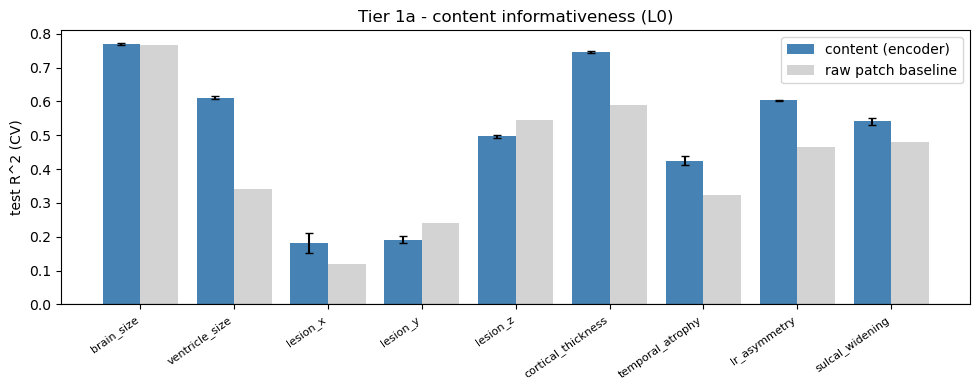


Partial R^2 controlling for SCM parents (causal run):
            factor  n_parents  full_r2  partial_r2
        brain_size          0    0.770       0.770
    ventricle_size          1    0.611       0.213
          lesion_x          1    0.182      -0.063
          lesion_y          2    0.192      -0.248
          lesion_z          3    0.497      -0.077
cortical_thickness          4    0.747       0.291
  temporal_atrophy          3    0.425       0.122
      lr_asymmetry          3    0.603       0.199
   sulcal_widening          2    0.541       0.020
  partial_r2 ~ full_r2  =>  encoder captures the factor's own variation, not just parents.


In [7]:
# ── Tier 1a — Content informativeness (per factor, k-fold CV, multi-seed) ────
cX, _ = patch_repr(PRIMARY_LEVEL, "content")
rows = idm.content_informativeness(cX, gt_content, content_names, raw_repr=raw_features["v1"],
                                   n_splits=CV_SPLITS, seeds=CV_SEEDS, kind=PROBE_KIND)
df_info = pd.DataFrame(rows)
df_info.insert(1, "type", ["spatial" if n in SPATIAL_FACTORS else "global" for n in df_info["factor"]])
print("Content block -> each GT content factor (test R^2, patch-pooled):")
print("  enc_mean = encoder,  raw_mean = patch-intensity baseline,  delta = encoder credit\n")
print(df_info.round(3).to_string(index=False))
print(f"\n  mean encoder R^2 = {df_info['enc_mean'].mean():.3f}   "
      f"(spatial: {df_info[df_info['type']=='spatial']['enc_mean'].mean():.3f}, "
      f"global: {df_info[df_info['type']=='global']['enc_mean'].mean():.3f})")

fig, ax = plt.subplots(figsize=(max(7, 1.1 * len(df_info)), 4))
x = np.arange(len(df_info))
ax.bar(x - 0.2, df_info["enc_mean"], 0.4, yerr=df_info["enc_std"], capsize=3, label="content (encoder)", color="steelblue")
ax.bar(x + 0.2, df_info["raw_mean"].clip(lower=-0.1), 0.4, label="raw patch baseline", color="lightgray")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_info["factor"], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("test R^2 (CV)")
ax.set_title(f"Tier 1a - content informativeness (L{PRIMARY_LEVEL})")
ax.legend()
plt.tight_layout()
plt.show()

if adjacency is not None:
    print("\nPartial R^2 controlling for SCM parents (causal run):")
    pr = idm.partial_r2_vs_parents(cX, gt_content, adjacency, content_names,
                                   n_splits=CV_SPLITS, seeds=CV_SEEDS, kind=PROBE_KIND)
    print(pd.DataFrame(pr).round(3).to_string(index=False))
    print("  partial_r2 ~ full_r2  =>  encoder captures the factor's own variation, not just parents.")

In [8]:
# ── Tier 1b — Content/style separation (sufficiency + view-invariance) ───────
cX, _ = patch_repr(PRIMARY_LEVEL, "content")
aX = all_repr(PRIMARY_LEVEL)
suff = idm.content_sufficiency(cX, aX, gt_content, content_names,
                               n_splits=CV_SPLITS, seeds=CV_SEEDS, kind=PROBE_KIND)
df_suff = pd.DataFrame(suff)
print("Content sufficiency - does adding style improve content-factor prediction?")
print(df_suff.round(3).to_string(index=False))
mean_delta = df_suff["delta"].mean()
verdict = ("PASS (content sufficient)" if abs(mean_delta) < 0.03
           else "FAIL (style carries shared info)" if mean_delta > 0.05 else "BORDERLINE")
print(f"  mean delta (style adds) = {mean_delta:+.3f}  ->  {verdict}")

cv1, _ = patch_repr(PRIMARY_LEVEL, "content", "v1")
cv2, _ = patch_repr(PRIMARY_LEVEL, "content", "v2")
sv1, _ = patch_repr(PRIMARY_LEVEL, "style", "v1")
sv2, _ = patch_repr(PRIMARY_LEVEL, "style", "v2")
vi = idm.view_invariance(cv1, cv2, sv1, sv2, all_repr(PRIMARY_LEVEL, "v1"), all_repr(PRIMARY_LEVEL, "v2"),
                         n_splits=CV_SPLITS, seeds=CV_SEEDS)
print("\nView-invariance (predict view id; content ~chance, style high):")
print(f"  content -> view : {vi['content_acc']:.3f}  (chance {vi['chance']:.2f})")
print(f"  style   -> view : {vi['style_acc']:.3f}")
print(f"  all     -> view : {vi.get('all_acc', float('nan')):.3f}")
ok = (vi["content_acc"] < 0.65) and (vi["style_acc"] > 0.80)
print("  -> " + ("PASS (content view-invariant, style view-specific)" if ok else "see values above"))

Content sufficiency - does adding style improve content-factor prediction?
            factor  content_r2  content_style_r2  delta
        brain_size       0.770             0.815  0.045
    ventricle_size       0.611             0.629  0.018
          lesion_x       0.182             0.199  0.016
          lesion_y       0.192             0.210  0.018
          lesion_z       0.497             0.532  0.035
cortical_thickness       0.747             0.762  0.015
  temporal_atrophy       0.425             0.505  0.079
      lr_asymmetry       0.603             0.631  0.029
   sulcal_widening       0.541             0.559  0.018
  mean delta (style adds) = +0.030  ->  BORDERLINE

View-invariance (predict view id; content ~chance, style high):
  content -> view : 0.437  (chance 0.50)
  style   -> view : 1.000
  all     -> view : 1.000
  -> PASS (content view-invariant, style view-specific)


In [9]:
# ── Tier 1c — Block-MCC (identifiability up to the allowed transform) ────────
cX, _ = patch_repr(PRIMARY_LEVEL, "content")
sX, _ = patch_repr(PRIMARY_LEVEL, "style")
mcc_c = idm.block_mcc(cX, gt_content, kind=PROBE_KIND, seeds=CV_SEEDS, n_splits=CV_SPLITS)
mcc_s = (idm.block_mcc(sX, gt_style, kind=PROBE_KIND, seeds=CV_SEEDS, n_splits=CV_SPLITS)
         if sX.shape[1] else {"mean": float("nan"), "std": float("nan")})
print("Block-MCC (fit readout, Hungarian-match, mean |corr|) - correct MCC for block identifiability:")
print(f"  content block -> z_content : {mcc_c['mean']:.3f} +/- {mcc_c['std']:.3f}")
print(f"  style   block -> z_style   : {mcc_s['mean']:.3f} +/- {mcc_s['std']:.3f}")

Block-MCC (fit readout, Hungarian-match, mean |corr|) - correct MCC for block identifiability:
  content block -> z_content : 0.711 +/- 0.002
  style   block -> z_style   : 0.109 +/- 0.009


## Tier 2 — useful, interpret with care

In [10]:
# ── Tier 2a — DCI informativeness matrix (the trustworthy part of DCI) ───────
cX, _ = patch_repr(PRIMARY_LEVEL, "content")
sX, _ = patch_repr(PRIMARY_LEVEL, "style")
sections = {
    "content->content": (cX, gt_content, content_names),
    "content->style": (cX, gt_style, style_names),
    "style->style": (sX, gt_style, style_names),
    "style->content": (sX, gt_content, content_names),
}
res = idm.dci_informativeness_sections(sections, n_splits=CV_SPLITS, seeds=CV_SEEDS, kind=PROBE_KIND)
print("DCI informativeness (mean test R^2, clipped) - matched pairs high, cross pairs low:")
for k in ["content->content", "content->style", "style->style", "style->content"]:
    print(f"  {k:18s}: {res[k]['mean_r2']:.3f}")
print("\nPer-factor (content->content):")
print(pd.Series(res["content->content"]["per_factor"]).round(3).to_string())

DCI informativeness (mean test R^2, clipped) - matched pairs high, cross pairs low:
  content->content  : 0.508
  content->style    : 0.000
  style->style      : 0.000
  style->content    : 0.550

Per-factor (content->content):
brain_size            0.770
ventricle_size        0.611
lesion_x              0.182
lesion_y              0.192
lesion_z              0.497
cortical_thickness    0.747
temporal_atrophy      0.425
lr_asymmetry          0.603
sulcal_widening       0.541


In [11]:
# ── Tier 2b — Probe-free cross-view consistency (no decoder needed) ──────────
cv1, _ = patch_repr(PRIMARY_LEVEL, "content", "v1")
cv2, _ = patch_repr(PRIMARY_LEVEL, "content", "v2")
sv1, _ = patch_repr(PRIMARY_LEVEL, "style", "v1")
sv2, _ = patch_repr(PRIMARY_LEVEL, "style", "v2")
cc = idm.crossview_consistency(cv1, cv2, sv1, sv2)
print("Cross-view cosine similarity (probe-free):")
print(f"  content, same subject across views : {cc['content_within_subject']:.3f}  (want high)")
print(f"  content, different subjects        : {cc['content_cross_subject']:.3f}  (baseline, want lower)")
print(f"  style,   same subject across views : {cc['style_within_subject']:.3f}  (want < content)")
gap = cc["content_within_subject"] - cc["content_cross_subject"]
print(f"  -> content within-vs-cross gap = {gap:+.3f}  ({'PASS' if gap > 0.2 else 'weak'})")

Cross-view cosine similarity (probe-free):
  content, same subject across views : 0.981  (want high)
  content, different subjects        : 0.011  (baseline, want lower)
  style,   same subject across views : 0.836  (want < content)
  -> content within-vs-cross gap = +0.969  (PASS)


In [12]:
# ── Tier 2c — Causal structure (partial R^2 beyond parents) ──────────────────
if adjacency is None:
    print("Not a causal run (--synthetic-causal off) - skipping. Graph recovery / "
          "interventional consistency live in analyze_synthetic_recovery.ipynb (7j/7k).")
else:
    cX, _ = patch_repr(PRIMARY_LEVEL, "content")
    pr = idm.partial_r2_vs_parents(cX, gt_content, adjacency, content_names,
                                   n_splits=CV_SPLITS, seeds=CV_SEEDS, kind=PROBE_KIND)
    dfp = pd.DataFrame(pr)
    dfp["own_signal"] = dfp["partial_r2"] / dfp["full_r2"].clip(lower=1e-6)
    print("Causal partial-R^2 (content captures each factor beyond its SCM parents):")
    print(dfp.round(3).to_string(index=False))
    print(f"\n  mean partial/full ratio = {dfp['own_signal'].clip(0, 1).mean():.3f}  (1.0 = fully own signal)")

Causal partial-R^2 (content captures each factor beyond its SCM parents):
            factor  n_parents  full_r2  partial_r2  own_signal
        brain_size          0    0.770       0.770       1.000
    ventricle_size          1    0.611       0.213       0.349
          lesion_x          1    0.182      -0.063      -0.347
          lesion_y          2    0.192      -0.248      -1.293
          lesion_z          3    0.497      -0.077      -0.155
cortical_thickness          4    0.747       0.291       0.390
  temporal_atrophy          3    0.425       0.122       0.286
      lr_asymmetry          3    0.603       0.199       0.330
   sulcal_widening          2    0.541       0.020       0.037

  mean partial/full ratio = 0.266  (1.0 = fully own signal)


## Tier 3 — component-wise (diagnostic; NOT a success criterion)

In [13]:
# ── Tier 3 — COMPONENT-WISE metrics (NOT claimed by the theory; diagnostic) ──
# Block identifiability does not promise one-channel-one-factor. Read these as
# "how close to axis-aligned did we get", NOT as success criteria. Under a causal
# SCM the disentanglement ceiling is < 1 regardless of the model (see ceiling).
cX, cg = patch_repr(PRIMARY_LEVEL, "content")
R = idm.importance_matrix(cX, gt_content, cg, method="rf_perm", seed=0)
dc = idm.dci_DC(R)
ceiling = idm.factor_correlation_ceiling(gt_content)
pcmcc = idm.per_channel_mcc(channel_repr(PRIMARY_LEVEL, "content"), gt_content)
print("Component-wise (aspirational) diagnostics:")
print(f"  DCI disentanglement : {dc['disentanglement']:.3f}")
print(f"  DCI completeness    : {dc['completeness']:.3f}")
print(f"  per-channel MCC     : {pcmcc:.3f}   (strict one-channel-one-factor)")
print(f"  factor-corr ceiling : {ceiling:.3f}   (mean |corr| among GT factors)")
if ceiling > 0.15:
    print("  ! factors are correlated -> DCI-D is bounded below 1; do not read low D as failure.")
print("  Reminder: these test a claim the model does NOT make. Headline on Tiers 1-2.")

Component-wise (aspirational) diagnostics:
  DCI disentanglement : 0.251
  DCI completeness    : 0.598
  per-channel MCC     : 0.340   (strict one-channel-one-factor)
  factor-corr ceiling : 0.558   (mean |corr| among GT factors)
  ! factors are correlated -> DCI-D is bounded below 1; do not read low D as failure.
  Reminder: these test a claim the model does NOT make. Headline on Tiers 1-2.


## Summary

In [14]:
# ── Summary panel — trustworthy verdict (Tiers 1-2 only) ─────────────────────
def _flag(ok):
    return "PASS" if ok else "----"

rows = [
    ("Tier1a content informativeness (mean)", df_info["enc_mean"].mean(), df_info["enc_mean"].mean() > 0.4),
    ("Tier1b content sufficiency |delta|", df_suff["delta"].mean(), abs(df_suff["delta"].mean()) < 0.05),
    ("Tier1b content->view (~chance)", vi["content_acc"], vi["content_acc"] < 0.65),
    ("Tier1b style->view (high)", vi["style_acc"], vi["style_acc"] > 0.80),
    ("Tier1c block-MCC content", mcc_c["mean"], mcc_c["mean"] > 0.6),
    ("Tier2a content->content I", res["content->content"]["mean_r2"], res["content->content"]["mean_r2"] > 0.4),
    ("Tier2a style->content I (low)", res["style->content"]["mean_r2"], res["style->content"]["mean_r2"] < 0.3),
    ("Tier2b content cross-view gap", cc["content_within_subject"] - cc["content_cross_subject"],
     (cc["content_within_subject"] - cc["content_cross_subject"]) > 0.2),
]
print("=" * 66)
print("IDENTIFIABILITY SUMMARY  (verdict from Tiers 1-2)")
print("=" * 66)
for name, val, ok in rows:
    print(f"  {_flag(ok)}  {name:38s} {val:+.3f}")
print("\nTier 3 (component-wise) numbers are diagnostic only - excluded from this verdict.")

IDENTIFIABILITY SUMMARY  (verdict from Tiers 1-2)
  PASS  Tier1a content informativeness (mean)  +0.508
  PASS  Tier1b content sufficiency |delta|     +0.030
  PASS  Tier1b content->view (~chance)         +0.437
  PASS  Tier1b style->view (high)              +1.000
  PASS  Tier1c block-MCC content               +0.711
  PASS  Tier2a content->content I              +0.508
  ----  Tier2a style->content I (low)          +0.550
  PASS  Tier2b content cross-view gap          +0.969

Tier 3 (component-wise) numbers are diagnostic only - excluded from this verdict.
